# Mumbai Indians (2024–2026): Bowling Phase-Split Root-Cause Analysis

This notebook investigates why Mumbai Indians' bowling attack declined across the 2024–2026 IPL seasons, using **ball-by-ball delivery data** (Cricsheet-derived) merged with **match metadata**, split into three phases per innings — **powerplay** (overs 1–6), **middle** (overs 7–15), and **death** (overs 16–20).

The analysis proceeds from raw data to six specific, numbers-grounded findings:

1. MI's bowling followed a **recovery-then-relapse arc**, not a straight decline — 2025 was genuinely their best season in every phase, and 2026 fell back below even 2024.
2. **Bumrah's decline is real and gradual** across three seasons, while **Boult's 2026 collapse rests on too small a sample** to explain the team-wide relapse alone.
3. The **2026 powerplay collapse** traces to a small group of all-rounders/part-timers pressed into new-ball overs, not to Bumrah or Boult individually.
4. The **death overs were even more concentrated** on one bowler (Bumrah), with the remainder fragmented across seven names in cameo roles.
5. The **middle overs show the same fragmentation pattern** — 13 different bowlers used, with Ghazanfar carrying the heaviest load and Corbin Bosch standing out as the notebook's best-hidden performer.
6. A concrete individual case — **Ashwani Kumar** — shows a fit, previously productive death-overs specialist rotated almost entirely out of that role in 2026, for tactical reasons rather than injury.
7. A **venue-level pace-vs-spin selection rule** for MI's bowling attack, built from their own three-season record at each ground.

A supplementary player-details CSV (batting/bowling hand and style) is merged into the working dataframe in Section 4, but is **not used** in the phase-split findings below — it's included for downstream matchup-specific work (e.g. batter-hand splits), which is carried out in the companion Batting Analysis notebook instead.

All `.to_csv()` exports used to build the accompanying dashboard are consolidated in the final section, after every finding in this notebook.

## 1. Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
sns.set_style("white")

# Okabe-Ito palette — the standard, peer-reviewed colorblind-safe palette,
# distinguishable under deuteranopia, protanopia, and tritanopia
GRAY = "#999999"      # neutral/context
ACCENT = "#D55E00"    # vermillion — the "problem/highlight" color
BLUE = "#0072B2"      # blue — the safest high-contrast pairing with vermillion
GREEN = "#009E73"     # bluish-green — for any chart needing a 3rd distinct hue 

## 2. Load ball-by-ball and match data

Two source files: per-delivery ball-by-ball data, and per-match metadata (teams, dates, venue, result). The match metadata needs a `season` column derived from the match date before it can be filtered.

In [2]:
ball_data = pd.read_csv("../data/Ball_By_Ball_Match_Data.csv")
ball_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 295732 entries, 0 to 295731
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   ID                295732 non-null  int64 
 1   Innings           295732 non-null  int64 
 2   Overs             295732 non-null  int64 
 3   BallNumber        295732 non-null  int64 
 4   Batter            295732 non-null  object
 5   Bowler            295732 non-null  object
 6   NonStriker        295732 non-null  object
 7   ExtraType         16227 non-null   object
 8   BatsmanRun        295732 non-null  int64 
 9   ExtrasRun         295732 non-null  int64 
 10  TotalRun          295732 non-null  int64 
 11  IsWicketDelivery  295732 non-null  int64 
 12  PlayerOut         14705 non-null   object
 13  Kind              14705 non-null   object
 14  FieldersInvolved  10721 non-null   object
 15  BattingTeam       295732 non-null  object
dtypes: int64(8), object(8)
memory usage: 3

In [3]:
match_data = pd.read_csv("../data/Match_Info.csv")
match_data.head(10)

,match_number,team1,team2,match_date,toss_winner,toss_decision,result,eliminator,winner,player_of_match,venue,city,team1_players,team2_players
0,501208,Deccan Chargers,Royal Challengers Bangalore,2011-04-14,Royal Challengers Bangalore,field,Win,NaN,Deccan Chargers,DW Steyn,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,"S Sohal, S Dhawan, KC Sangakkara, B Chipli, JP...","MA Agarwal, TM Dilshan, Z Khan, V Kohli, AB de..."
1,1216505,Royal Challengers Bangalore,Delhi Capitals,2020-11-02,Delhi Capitals,field,Win,NaN,Delhi Capitals,A Nortje,Sheikh Zayed Stadium,Abu Dhabi,"JR Philippe, D Padikkal, V Kohli, AB de Villie...","PP Shaw, S Dhawan, AM Rahane, SS Iyer, RR Pant..."
2,1359481,Delhi Capitals,Gujarat Titans,2023-04-04,Gujarat Titans,field,Win,NaN,Gujarat Titans,B Sai Sudharsan,"Arun Jaitley Stadium, Delhi",Delhi,"KK Ahmed, DA Warner, PP Shaw, MR Marsh, SN Kha...","J Little, WP Saha, Shubman Gill, B Sai Sudhars..."
3,1178398,Kolkata Knight Riders,Chennai Super Kings,2019-04-09,Chennai Super Kings,field,Win,NaN,Chennai Super Kings,DL Chahar,MA Chidambaram Stadium,Chennai,"CA Lynn, SP Narine, RV Uthappa, N Rana, KD Kar...","SR Watson, F du Plessis, SK Raina, AT Rayudu, ..."
4,1529313,Delhi Capitals,Kolkata Knight Riders,2026-05-24,Kolkata Knight Riders,field,Win,NaN,Delhi Capitals,Kuldeep Yadav,"Eden Gardens, Kolkata",Kolkata,"Kuldeep Yadav, Abishek Porel, KL Rahul, SU Par...","SP Narine, AM Rahane, FH Allen, MK Pandey, C G..."
5,1304095,Royal Challengers Bangalore,Chennai Super Kings,2022-05-04,Chennai Super Kings,field,Win,NaN,Royal Challengers Bangalore,HV Patel,"Maharashtra Cricket Association Stadium, Pune",Pune,"V Kohli, F du Plessis, GJ Maxwell, MK Lomror, ...","RD Gaikwad, DP Conway, RV Uthappa, AT Rayudu, ..."
6,1178404,Kolkata Knight Riders,Chennai Super Kings,2019-04-14,Chennai Super Kings,field,Win,NaN,Chennai Super Kings,Imran Tahir,Eden Gardens,Kolkata,"CA Lynn, SP Narine, N Rana, RV Uthappa, KD Kar...","SR Watson, F du Plessis, SK Raina, AT Rayudu, ..."
7,980979,Rising Pune Supergiants,Sunrisers Hyderabad,2016-05-10,Sunrisers Hyderabad,bat,Win,NaN,Sunrisers Hyderabad,A Zampa,Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket St...,Visakhapatnam,"AM Rahane, UT Khawaja, GJ Bailey, R Ashwin, SS...","DA Warner, S Dhawan, KS Williamson, Yuvraj Sin..."
8,1529311,Lucknow Super Giants,Punjab Kings,2026-05-23,Punjab Kings,field,Win,NaN,Punjab Kings,SS Iyer,Bharat Ratna Shri Atal Bihari Vajpayee Ekana C...,Lucknow,"DS Rathi, JP Inglis, AA Kulkarni, N Pooran, A ...","YS Chahal, Priyansh Arya, P Simran Singh, C Co..."
9,734045,Chennai Super Kings,Mumbai Indians,2014-05-28,Chennai Super Kings,field,Win,NaN,Chennai Super Kings,SK Raina,Brabourne Stadium,Mumbai,"DR Smith, F du Plessis, SK Raina, BB McCullum,...","LMP Simmons, MEK Hussey, CJ Anderson, RG Sharm..."


In [4]:
match_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1243 entries, 0 to 1242
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   match_number     1243 non-null   int64 
 1   team1            1243 non-null   object
 2   team2            1243 non-null   object
 3   match_date       1243 non-null   object
 4   toss_winner      1243 non-null   object
 5   toss_decision    1243 non-null   object
 6   result           1243 non-null   object
 7   eliminator       16 non-null     object
 8   winner           1218 non-null   object
 9   player_of_match  1243 non-null   object
 10  venue            1243 non-null   object
 11  city             1192 non-null   object
 12  team1_players    1243 non-null   object
 13  team2_players    1243 non-null   object
dtypes: int64(1), object(13)
memory usage: 136.1+ KB


In [5]:
match_data['match_date'] = pd.to_datetime(match_data['match_date'])
match_data['season'] = match_data['match_date'].dt.year
match_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1243 entries, 0 to 1242
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   match_number     1243 non-null   int64         
 1   team1            1243 non-null   object        
 2   team2            1243 non-null   object        
 3   match_date       1243 non-null   datetime64[ns]
 4   toss_winner      1243 non-null   object        
 5   toss_decision    1243 non-null   object        
 6   result           1243 non-null   object        
 7   eliminator       16 non-null     object        
 8   winner           1218 non-null   object        
 9   player_of_match  1243 non-null   object        
 10  venue            1243 non-null   object        
 11  city             1192 non-null   object        
 12  team1_players    1243 non-null   object        
 13  team2_players    1243 non-null   object        
 14  season           1243 non-null   int32  

## 3. Filter to the 2024–2026 seasons and merge

Filtering match metadata down to the three seasons in scope, then merging it onto the ball-by-ball data on the match ID. `BowlingTeam` isn't present in the raw delivery data — only `BattingTeam` is — so it's derived as whichever of `team1`/`team2` isn't currently batting.

In [6]:
years = [2024,2025,2026]

matches_relevant = match_data[match_data['season'].isin(years)]
matches_relevant

,match_number,team1,team2,match_date,toss_winner,toss_decision,result,eliminator,winner,player_of_match,venue,city,team1_players,team2_players,season
4,1529313,Delhi Capitals,Kolkata Knight Riders,2026-05-24,Kolkata Knight Riders,field,Win,NaN,Delhi Capitals,Kuldeep Yadav,"Eden Gardens, Kolkata",Kolkata,"Kuldeep Yadav, Abishek Porel, KL Rahul, SU Par...","SP Narine, AM Rahane, FH Allen, MK Pandey, C G...",2026
8,1529311,Lucknow Super Giants,Punjab Kings,2026-05-23,Punjab Kings,field,Win,NaN,Punjab Kings,SS Iyer,Bharat Ratna Shri Atal Bihari Vajpayee Ekana C...,Lucknow,"DS Rathi, JP Inglis, AA Kulkarni, N Pooran, A ...","YS Chahal, Priyansh Arya, P Simran Singh, C Co...",2026
19,1426271,Mumbai Indians,Punjab Kings,2024-04-18,Punjab Kings,field,Win,NaN,Mumbai Indians,JJ Bumrah,Maharaja Yadavindra Singh International Cricke...,Mohali,"Akash Madhwal, Ishan Kishan, RG Sharma, SA Yad...","Arshdeep Singh, SM Curran, P Simran Singh, RR ...",2024
25,1426283,Gujarat Titans,Royal Challengers Bengaluru,2024-04-28,Royal Challengers Bengaluru,field,Win,NaN,Royal Challengers Bengaluru,WG Jacks,"Narendra Modi Stadium, Ahmedabad",Ahmedabad,"S Sandeep Warrier, WP Saha, Shubman Gill, B Sa...","V Kohli, F du Plessis, WG Jacks, RM Patidar, G...",2024
29,1426269,Kolkata Knight Riders,Rajasthan Royals,2024-04-16,Rajasthan Royals,field,Win,NaN,Rajasthan Royals,JC Buttler,"Eden Gardens, Kolkata",Kolkata,"VG Arora, PD Salt, SP Narine, A Raghuvanshi, S...","KR Sen, YBK Jaiswal, JC Buttler, SV Samson, R ...",2024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1220,1422129,Lucknow Super Giants,Punjab Kings,2024-03-30,Lucknow Super Giants,bat,Win,NaN,Lucknow Super Giants,MP Yadav,Bharat Ratna Shri Atal Bihari Vajpayee Ekana C...,Lucknow,"Q de Kock, KL Rahul, D Padikkal, MP Stoinis, N...","Arshdeep Singh, S Dhawan, JM Bairstow, P Simra...",2024
1222,1473487,Mumbai Indians,Rajasthan Royals,2025-05-01,Rajasthan Royals,field,Win,NaN,Mumbai Indians,RD Rickelton,"Sawai Mansingh Stadium, Jaipur",Jaipur,"KV Sharma, RD Rickelton, RG Sharma, SA Yadav, ...","Fazalhaq Farooqi, YBK Jaiswal, V Suryavanshi, ...",2025
1227,1529309,Gujarat Titans,Chennai Super Kings,2026-05-21,Chennai Super Kings,field,Win,NaN,Gujarat Titans,Mohammed Siraj,"Narendra Modi Stadium, Ahmedabad",Ahmedabad,"M Prasidh Krishna, B Sai Sudharsan, Shubman Gi...","Gurjapneet Singh, SV Samson, MW Short, RD Gaik...",2026
1232,1422123,Gujarat Titans,Mumbai Indians,2024-03-24,Mumbai Indians,field,Win,NaN,Gujarat Titans,B Sai Sudharsan,"Narendra Modi Stadium, Ahmedabad",Ahmedabad,"MM Sharma, WP Saha, Shubman Gill, B Sai Sudhar...","L Wood, Ishan Kishan, RG Sharma, Naman Dhir, D...",2024


In [7]:
matches_relevant.info()

<class 'pandas.core.frame.DataFrame'>
Index: 219 entries, 4 to 1237
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   match_number     219 non-null    int64         
 1   team1            219 non-null    object        
 2   team2            219 non-null    object        
 3   match_date       219 non-null    datetime64[ns]
 4   toss_winner      219 non-null    object        
 5   toss_decision    219 non-null    object        
 6   result           219 non-null    object        
 7   eliminator       2 non-null      object        
 8   winner           213 non-null    object        
 9   player_of_match  219 non-null    object        
 10  venue            219 non-null    object        
 11  city             219 non-null    object        
 12  team1_players    219 non-null    object        
 13  team2_players    219 non-null    object        
 14  season           219 non-null    int32        

**Check:** 219 matches in scope (71 in 2024, 74 each in 2025/2026) — confirmed against the official season match counts before proceeding, and separately confirmed that Mumbai Indians' own 14-match slice for 2024 (their non-playoff season) is complete despite the season-wide total falling 3 matches short of the full 74.

In [8]:
final_data = pd.merge(
    ball_data,
    matches_relevant[['match_number', 'season', 'team1', 'team2', 'venue', 'match_date', 'winner']],
    left_on="ID", right_on="match_number", how="inner"
)

In [9]:
final_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51915 entries, 0 to 51914
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   ID                51915 non-null  int64         
 1   Innings           51915 non-null  int64         
 2   Overs             51915 non-null  int64         
 3   BallNumber        51915 non-null  int64         
 4   Batter            51915 non-null  object        
 5   Bowler            51915 non-null  object        
 6   NonStriker        51915 non-null  object        
 7   ExtraType         3168 non-null   object        
 8   BatsmanRun        51915 non-null  int64         
 9   ExtrasRun         51915 non-null  int64         
 10  TotalRun          51915 non-null  int64         
 11  IsWicketDelivery  51915 non-null  int64         
 12  PlayerOut         2638 non-null   object        
 13  Kind              2638 non-null   object        
 14  FieldersInvolved  2058

In [10]:
final_data = final_data.drop(columns=['match_number'])

In [11]:
final_data.head(20)

,ID,Innings,Overs,BallNumber,Batter,Bowler,NonStriker,ExtraType,BatsmanRun,ExtrasRun,...,PlayerOut,Kind,FieldersInvolved,BattingTeam,season,team1,team2,venue,match_date,winner
0,1529313,1,0,1,Abishek Porel,AS Roy,KL Rahul,NaN,0,0,...,NaN,NaN,NaN,Delhi Capitals,2026,Delhi Capitals,Kolkata Knight Riders,"Eden Gardens, Kolkata",2026-05-24,Delhi Capitals
1,1529313,1,0,2,Abishek Porel,AS Roy,KL Rahul,NaN,0,0,...,NaN,NaN,NaN,Delhi Capitals,2026,Delhi Capitals,Kolkata Knight Riders,"Eden Gardens, Kolkata",2026-05-24,Delhi Capitals
2,1529313,1,0,3,Abishek Porel,AS Roy,KL Rahul,NaN,4,0,...,NaN,NaN,NaN,Delhi Capitals,2026,Delhi Capitals,Kolkata Knight Riders,"Eden Gardens, Kolkata",2026-05-24,Delhi Capitals
3,1529313,1,0,4,Abishek Porel,AS Roy,KL Rahul,NaN,4,0,...,NaN,NaN,NaN,Delhi Capitals,2026,Delhi Capitals,Kolkata Knight Riders,"Eden Gardens, Kolkata",2026-05-24,Delhi Capitals
4,1529313,1,0,5,Abishek Porel,AS Roy,KL Rahul,NaN,1,0,...,NaN,NaN,NaN,Delhi Capitals,2026,Delhi Capitals,Kolkata Knight Riders,"Eden Gardens, Kolkata",2026-05-24,Delhi Capitals
5,1529313,1,0,6,KL Rahul,AS Roy,Abishek Porel,NaN,1,0,...,NaN,NaN,NaN,Delhi Capitals,2026,Delhi Capitals,Kolkata Knight Riders,"Eden Gardens, Kolkata",2026-05-24,Delhi Capitals
6,1529313,1,1,1,KL Rahul,SR Dubey,Abishek Porel,NaN,0,0,...,NaN,NaN,NaN,Delhi Capitals,2026,Delhi Capitals,Kolkata Knight Riders,"Eden Gardens, Kolkata",2026-05-24,Delhi Capitals
7,1529313,1,1,2,KL Rahul,SR Dubey,Abishek Porel,NaN,1,0,...,NaN,NaN,NaN,Delhi Capitals,2026,Delhi Capitals,Kolkata Knight Riders,"Eden Gardens, Kolkata",2026-05-24,Delhi Capitals
8,1529313,1,1,3,Abishek Porel,SR Dubey,KL Rahul,NaN,0,0,...,NaN,NaN,NaN,Delhi Capitals,2026,Delhi Capitals,Kolkata Knight Riders,"Eden Gardens, Kolkata",2026-05-24,Delhi Capitals
9,1529313,1,1,4,Abishek Porel,SR Dubey,KL Rahul,NaN,0,0,...,NaN,NaN,NaN,Delhi Capitals,2026,Delhi Capitals,Kolkata Knight Riders,"Eden Gardens, Kolkata",2026-05-24,Delhi Capitals


In [12]:
final_data['BowlingTeam'] = final_data.apply(
    lambda r: r['team2'] if r['BattingTeam'] == r['team1'] else r['team1'], axis=1
)

## 4. Player metadata: patching known gaps

A supplementary player-details CSV supplies batting/bowling hand and style. It was compiled before three current MI players joined the squad, so those three (Ryan Rickelton, Ashwani Kumar, Corbin Bosch) are patched in manually, with their batting/bowling styles verified individually rather than guessed. This metadata isn't used in this notebook's own findings — it's retained here since it's merged as part of the shared data-preparation pipeline this notebook and its companion Batting Analysis notebook both build from.

In [13]:
import pandas as pd

meta = pd.read_csv("../data/2024_players_details.csv")
meta = meta[["Name", "longName", "battingName", "battingStyles", "bowlingStyles"]]
meta.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 261 entries, 0 to 260
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Name           261 non-null    object
 1   longName       261 non-null    object
 2   battingName    261 non-null    object
 3   battingStyles  261 non-null    object
 4   bowlingStyles  261 non-null    object
dtypes: object(5)
memory usage: 10.3+ KB


In [14]:
missing_players = pd.DataFrame([
    {
        "Name": "RD Rickelton", "longName": "Ryan Rickelton",
        "battingName": "RD Rickelton",
        "battingStyles": "lhb", "bowlingStyles": "sla"
    },
    {
        "Name": "Ashwani Kumar", "longName": "Ashwani Kumar",
        "battingName": "Ashwani Kumar",
        "battingStyles": "lhb", "bowlingStyles": "lmf"
    },
    {
        "Name": "Corbin Bosch", "longName": "Corbin Bosch",
        "battingName": "Corbin Bosch",
        "battingStyles": "rhb", "bowlingStyles": "rfm"
    },
])

meta = pd.concat([meta, missing_players], ignore_index=True)
meta.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264 entries, 0 to 263
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Name           264 non-null    object
 1   longName       264 non-null    object
 2   battingName    264 non-null    object
 3   battingStyles  264 non-null    object
 4   bowlingStyles  264 non-null    object
dtypes: object(5)
memory usage: 10.4+ KB


## 5. Feature engineering: match phase

Each delivery is tagged with its phase from the `Overs` column. **The indexing is checked before trusting the cutoffs** — misclassifying overs 6 or 15 would quietly distort exactly the death-overs numbers this analysis depends on.

In [15]:
print("Overs range:", final_data['Overs'].min(), "to", final_data['Overs'].max())

Overs range: 0 to 19


Confirmed 0-indexed (0 to 19), so the cutoffs below (`< 6`, `< 15`) are correct as written.

In [16]:
def get_phase(over):
    if over < 6:        # overs 1-6 (or 0-5 if 0-indexed)
        return "powerplay"
    elif over < 15:      # overs 7-15
        return "middle"
    else:                 # overs 16-20
        return "death"
final_data['phase'] = final_data['Overs'].apply(get_phase)
final_data['is_legal_ball'] = ~final_data['ExtraType'].isin(['wides', 'noballs','byes,noballs','legbyes,noballs'])


## 6. MI bowling splits, by season and phase

The foundational table for the whole analysis — MI's bowling output broken down by season and match phase. Everything from here on drills into specific rows of this table.

In [17]:
mi_bowling = final_data[final_data['BowlingTeam'] == 'Mumbai Indians']

bowling_split = mi_bowling.groupby(['season', 'phase']).agg(
    runs_conceded=('TotalRun', 'sum'),
    legal_balls=('is_legal_ball', 'sum'),
    wickets_taken=('IsWicketDelivery', 'sum'),
).reset_index()

bowling_split['economy'] = (bowling_split['runs_conceded'] / bowling_split['legal_balls'] * 6).round(2)

bowling_split

,season,phase,runs_conceded,legal_balls,wickets_taken,economy
0,2024,death,648,351,32,11.08
1,2024,middle,1241,756,30,9.85
2,2024,powerplay,771,504,23,9.18
3,2025,death,663,393,45,10.12
4,2025,middle,1175,864,45,8.16
5,2025,powerplay,878,576,26,9.15
6,2026,death,574,307,21,11.22
7,2026,middle,1152,732,30,9.44
8,2026,powerplay,910,504,24,10.83


In [18]:
phase_order = ['powerplay', 'middle', 'death']
bowling_split['phase'] = pd.Categorical(bowling_split['phase'], categories=phase_order, ordered=True)
print("\n=== MI Bowling split by season/phase ===")
bowling_split



=== MI Bowling split by season/phase ===


,season,phase,runs_conceded,legal_balls,wickets_taken,economy
0,2024,death,648,351,32,11.08
1,2024,middle,1241,756,30,9.85
2,2024,powerplay,771,504,23,9.18
3,2025,death,663,393,45,10.12
4,2025,middle,1175,864,45,8.16
5,2025,powerplay,878,576,26,9.15
6,2026,death,574,307,21,11.22
7,2026,middle,1152,732,30,9.44
8,2026,powerplay,910,504,24,10.83


The trend from the table above, visualized:

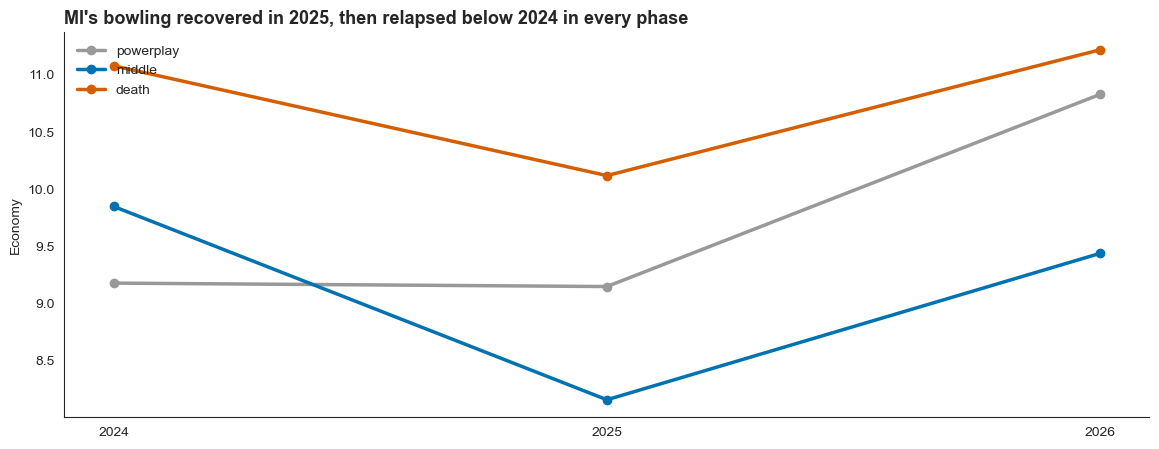

In [20]:
fig, ax1 = plt.subplots(figsize=(14, 5))
for phase, color in zip(['powerplay', 'middle', 'death'], [GRAY, BLUE, ACCENT]):
    sub = bowling_split[bowling_split['phase'] == phase].sort_values('season')
    ax1.plot(sub['season'], sub['economy'], marker='o', linewidth=2.5, color=color, label=phase)
ax1.set_title("MI's bowling recovered in 2025, then relapsed below 2024 in every phase",
              fontsize=13, fontweight='bold', loc='left')
ax1.legend(frameon=False, loc='upper left')
ax1.spines[['top', 'right']].set_visible(False)
ax1.set_xticks([2024, 2025, 2026])
ax1.set_ylabel("Economy")
plt.savefig("../dashboard_data/chart1_team_economy.png", dpi=200, bbox_inches='tight')
plt.show()

**Finding — MI's bowling followed a "recovery, then relapse" arc, not a straight decline.**

| Phase | 2024 | 2025 | 2026 |
|---|---|---|---|
| Powerplay | 9.18 | 9.15 | **10.83** |
| Middle | 9.85 | 8.16 | 9.44 |
| Death | 11.08 | **10.12** | **11.22** |

Middle and death overs show the same shape: **2025 was genuinely MI's best bowling season across the board, and 2026 didn't just fail to build on it — it fell back below 2024.**

Death-overs *penetration* collapsed alongside economy. Balls per wicket: 2024 ≈ **11.0**, 2025 ≈ **8.7** (sharpest), 2026 ≈ **14.6** (bluntest — barely half the wicket-taking rate of 2025). 2026's death bowling wasn't just leakier, it was taking wickets at roughly half the 2025 rate — a simultaneous collapse in control and penetration.

## 7. Bumrah and Boult: phase-split economy by season

Isolating MI's two frontline overseas/strike seamers to check whether the 2026 relapse traces back to them specifically. (Held in `bumrah_boult_split`, a name distinct from the full-squad `bowler_split` built in Section 8, so the two don't overwrite each other.)

In [21]:
key_bowlers = ['JJ Bumrah', 'TA Boult']  # adjust to match exact names in your data — check first:
print("Bumrah name variants:", mi_bowling[mi_bowling['Bowler'].str.contains('Bumrah', na=False)]['Bowler'].unique())
print("Boult name variants:", mi_bowling[mi_bowling['Bowler'].str.contains('Boult', na=False)]['Bowler'].unique())

Bumrah name variants: ['JJ Bumrah']
Boult name variants: ['TA Boult']


In [22]:
bumrah_boult_split = mi_bowling[mi_bowling['Bowler'].isin(key_bowlers)].groupby(
    ['Bowler', 'season', 'phase']
).agg(
    runs_conceded=('TotalRun', 'sum'),
    legal_balls=('is_legal_ball', 'sum'),
    wickets_taken=('IsWicketDelivery', 'sum'),
).reset_index()
bumrah_boult_split['economy'] = (bumrah_boult_split['runs_conceded'] / bumrah_boult_split['legal_balls'] * 6).round(2)
bumrah_boult_split['overs_bowled'] = (bumrah_boult_split['legal_balls'] / 6).round(1)

bumrah_boult_split['phase'] = pd.Categorical(bumrah_boult_split['phase'], categories=phase_order, ordered=True)
bumrah_boult_split = bumrah_boult_split.sort_values(['Bowler', 'season', 'phase'])


In [23]:
print("\n=== Bumrah & Boult: phase-split economy by season ===")
bumrah_boult_split



=== Bumrah & Boult: phase-split economy by season ===


,Bowler,season,phase,runs_conceded,legal_balls,wickets_taken,economy,overs_bowled
2,JJ Bumrah,2024,powerplay,128,126,6,6.10,21.0
1,JJ Bumrah,2024,middle,101,84,4,7.21,14.0
0,JJ Bumrah,2024,death,112,101,11,6.65,16.8
5,JJ Bumrah,2025,powerplay,123,90,4,8.20,15.0
4,JJ Bumrah,2025,middle,84,96,4,5.25,16.0
3,JJ Bumrah,2025,death,115,98,13,7.04,16.3
8,JJ Bumrah,2026,powerplay,218,144,3,9.08,24.0
7,JJ Bumrah,2026,middle,93,72,1,7.75,12.0
6,JJ Bumrah,2026,death,109,78,1,8.38,13.0
11,TA Boult,2025,powerplay,259,180,10,8.63,30.0


In [24]:
print("\n=== Powerplay only ===")
bumrah_boult_split[bumrah_boult_split['phase'] == 'powerplay']



=== Powerplay only ===


,Bowler,season,phase,runs_conceded,legal_balls,wickets_taken,economy,overs_bowled
2,JJ Bumrah,2024,powerplay,128,126,6,6.10,21.0
5,JJ Bumrah,2025,powerplay,123,90,4,8.20,15.0
8,JJ Bumrah,2026,powerplay,218,144,3,9.08,24.0
11,TA Boult,2025,powerplay,259,180,10,8.63,30.0
14,TA Boult,2026,powerplay,109,48,0,13.62,8.0


In [25]:
bumrah_death = bumrah_boult_split[(bumrah_boult_split['Bowler'] == 'JJ Bumrah') & (bumrah_boult_split['phase'] == 'death')]
print("\n=== Bumrah's death-overs workload by season ===")
bumrah_death[['season', 'overs_bowled', 'economy']]



=== Bumrah's death-overs workload by season ===


,season,overs_bowled,economy
0,2024,16.8,6.65
3,2025,16.3,7.04
6,2026,13.0,8.38


Their death-overs trajectories, side by side:

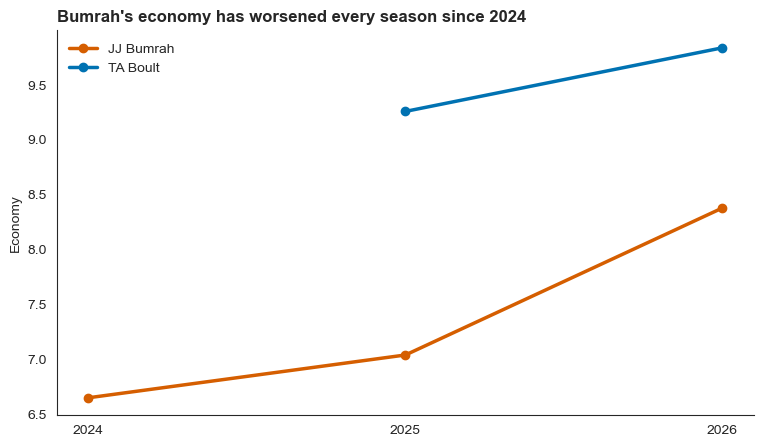

In [26]:
fig, ax4 = plt.subplots(figsize=(9, 5))
bb = bumrah_boult_split[(bumrah_boult_split['Bowler'].isin(['JJ Bumrah', 'TA Boult'])) & (bumrah_boult_split['phase'] == 'death')]
for bowler, color in zip(['JJ Bumrah', 'TA Boult'], [ACCENT, BLUE]):
    sub = bb[bb['Bowler'] == bowler].sort_values('season')
    ax4.plot(sub['season'], sub['economy'], marker='o', linewidth=2.5, color=color, label=bowler)
ax4.set_title("Bumrah's economy has worsened every season since 2024",
              fontsize=12, fontweight='bold', loc='left')
ax4.legend(frameon=False)
ax4.spines[['top', 'right']].set_visible(False)
ax4.set_xticks([2024, 2025, 2026])
ax4.set_ylabel("Economy")
plt.savefig("../dashboard_data/chart4_bumrah_boult.png", dpi=200, bbox_inches='tight')
plt.show()


**Finding — Bumrah's decline is real and gradual; Boult's 2026 sample is too small to explain the team-wide collapse alone.**

Bumrah's economy worsened **every single season, in every single phase**: powerplay 6.10 → 8.20 → 9.08; death 6.65 → 7.04 → 8.38 — a steady three-year decline, not a sudden 2026 cliff. Notably, MI actually gave him **fewer** death overs in 2026 (13.0) than in 2024 (16.8) or 2025 (16.3), and his economy still worsened — the data doesn't support a "just bowl him more" fix; his per-over effectiveness has declined independent of usage.

Boult's 2026 powerplay economy (13.62) is genuinely bad, but he only bowled **8 of MI's 84 powerplay overs** that season — under 10% of the workload, too small a sample to be the main driver of the team-wide powerplay collapse (team average 10.83).

## 8. Who actually drove the 2026 powerplay collapse?

Breaking the full powerplay workload down by every MI bowler that season — not just Bumrah and Boult — to find who's really behind the team-wide 10.83 economy. This also builds the full-squad `bowler_split` table used for the rest of the notebook and the final dashboard export.

In [27]:
bowler_split = mi_bowling.groupby(
    ['Bowler', 'season', 'phase']
).agg(
    runs_conceded=('TotalRun', 'sum'),
    legal_balls=('is_legal_ball', 'sum'),
    wickets_taken=('IsWicketDelivery', 'sum'),
).reset_index()
bowler_split['economy'] = (bowler_split['runs_conceded'] / bowler_split['legal_balls'] * 6).round(2)
bowler_split['overs_bowled'] = (bowler_split['legal_balls'] / 6).round(1)

bowler_split['phase'] = pd.Categorical(bowler_split['phase'], categories=phase_order, ordered=True)
bowler_split = bowler_split.sort_values(['Bowler', 'season', 'phase'])

bowler_split

,Bowler,season,phase,runs_conceded,legal_balls,wickets_taken,economy,overs_bowled
1,A Kamboj,2024,powerplay,62,30,1,12.40,5.0
0,A Kamboj,2024,middle,53,30,1,10.60,5.0
4,AM Ghazanfar,2026,powerplay,108,60,7,10.80,10.0
3,AM Ghazanfar,2026,middle,208,138,4,9.04,23.0
2,AM Ghazanfar,2026,death,74,35,4,12.69,5.8
...,...,...,...,...,...,...,...,...
114,WG Jacks,2025,middle,83,66,5,7.55,11.0
113,WG Jacks,2025,death,12,6,0,12.00,1.0
118,WG Jacks,2026,powerplay,51,24,1,12.75,4.0
117,WG Jacks,2026,middle,36,24,1,9.00,4.0


In [28]:
# ── Full powerplay breakdown, 2026, all MI bowlers ───────────────────
# Finds exactly who's driving the "everyone else" 11.21 economy figure

pp_2026 = mi_bowling[
    (mi_bowling['season'] == 2026) & (mi_bowling['phase'] == 'powerplay')
].groupby('Bowler').agg(
    runs_conceded=('TotalRun', 'sum'),
    legal_balls=('is_legal_ball', 'sum'),
    wickets_taken=('IsWicketDelivery', 'sum'),
).reset_index()

pp_2026['economy'] = (pp_2026['runs_conceded'] / pp_2026['legal_balls'] * 6).round(2)
pp_2026['overs_bowled'] = (pp_2026['legal_balls'] / 6).round(1)

# sort by overs bowled — the bowlers who actually carried the powerplay workload
pp_2026 = pp_2026.sort_values('overs_bowled', ascending=False)



In [29]:
print("=== MI powerplay bowling, 2026 — all bowlers ===")
pp_2026

=== MI powerplay bowling, 2026 — all bowlers ===


,Bowler,runs_conceded,legal_balls,wickets_taken,economy,overs_bowled
5,JJ Bumrah,218,144,3,9.08,24.0
3,DL Chahar,159,102,6,9.35,17.0
0,AM Ghazanfar,108,60,7,10.80,10.0
4,HH Pandya,111,48,1,13.88,8.0
9,TA Boult,109,48,0,13.62,8.0
8,SN Thakur,59,24,2,14.75,4.0
10,WG Jacks,51,24,1,12.75,4.0
6,Krish Bhagat,28,18,0,9.33,3.0
7,MJ Santner,41,18,1,13.67,3.0
2,C Bosch,20,12,2,10.00,2.0


Who actually bowled those overs — sorted by workload, not economy alone:

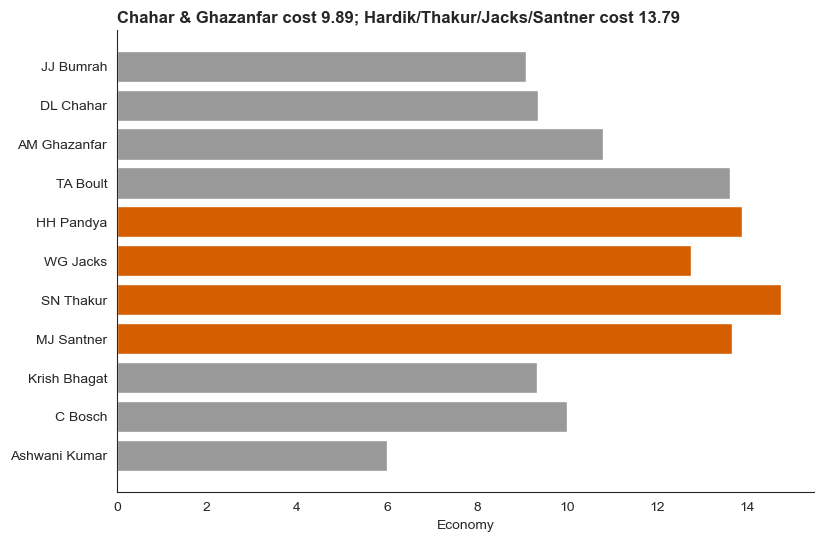

In [31]:
fig, ax2 = plt.subplots(figsize=(9, 6))
pp = pp_2026.sort_values('overs_bowled')
highlight_pp = {'HH Pandya', 'SN Thakur', 'WG Jacks', 'MJ Santner'}
colors_pp = [ACCENT if b in highlight_pp else GRAY for b in pp['Bowler']]
ax2.barh(pp['Bowler'], pp['economy'], color=colors_pp)
ax2.set_title("Chahar & Ghazanfar cost 9.89; Hardik/Thakur/Jacks/Santner cost 13.79",
              fontsize=12, fontweight='bold', loc='left')
ax2.spines[['top', 'right']].set_visible(False)
ax2.set_xlabel("Economy")
plt.savefig("../dashboard_data/chart2_powerplay_2026.png", dpi=200, bbox_inches='tight')
plt.show()

**Finding — the powerplay collapse was a personnel-gap problem, not a Bumrah/Boult problem.**

| Bowler | Overs | Economy | Wickets |
|---|---|---|---|
| DL Chahar | 17.0 | 9.35 | 6 |
| AM Ghazanfar | 10.0 | 10.80 | 7 |
| **HH Pandya** | **8.0** | **13.88** | **1** |
| **TA Boult** | 8.0 | 13.62 | 0 |
| **SN Thakur** | **4.0** | **14.75** | **2** |
| **WG Jacks** | **4.0** | **12.75** | **1** |
| **MJ Santner** | **3.0** | **13.67** | **1** |

Chahar and Ghazanfar — MI's two genuine new-ball options that season — combined for 27 overs at a perfectly reasonable **9.89 economy**, in line with MI's 2025 team average.

The damage is concentrated in bowlers who are **not specialist powerplay options**: Hardik Pandya, Shardul Thakur, Will Jacks, and Mitchell Santner combined for **19 overs, 262 runs conceded, just 5 wickets, and a 13.79 economy** — nearly a run a ball, from over a third of MI's non-Bumrah/Boult powerplay overs. **MI didn't have a genuine fourth seam option in 2026, so they patched the gap with all-rounders — at a cost of nearly 14 runs an over every time.**

## 9. The death overs: even more concentrated

In [32]:
death_2026 = mi_bowling[
    (mi_bowling['season'] == 2026) & (mi_bowling['phase'] == 'death')
].groupby('Bowler').agg(
    runs_conceded=('TotalRun', 'sum'),
    legal_balls=('is_legal_ball', 'sum'),
    wickets_taken=('IsWicketDelivery', 'sum'),
).reset_index()

death_2026['economy'] = (death_2026['runs_conceded'] / death_2026['legal_balls'] * 6).round(2)
death_2026['overs_bowled'] = (death_2026['legal_balls'] / 6).round(1)

# sort by overs bowled — the bowlers who actually carried the death workload
death_2026 = death_2026.sort_values('overs_bowled', ascending=False)

In [33]:
print("=== MI death bowling, 2026 — all bowlers ===")
death_2026

=== MI death bowling, 2026 — all bowlers ===


,Bowler,runs_conceded,legal_balls,wickets_taken,economy,overs_bowled
5,JJ Bumrah,109,78,1,8.38,13.0
2,C Bosch,76,37,4,12.32,6.2
10,SN Thakur,73,36,4,12.17,6.0
0,AM Ghazanfar,74,35,4,12.69,5.8
3,DL Chahar,66,33,2,12.00,5.5
11,TA Boult,41,25,2,9.84,4.2
6,Krish Bhagat,35,18,0,11.67,3.0
4,HH Pandya,42,16,1,15.75,2.7
1,Ashwani Kumar,15,6,1,15.00,1.0
7,MJ Santner,7,6,1,7.00,1.0


The same cut for the death overs:

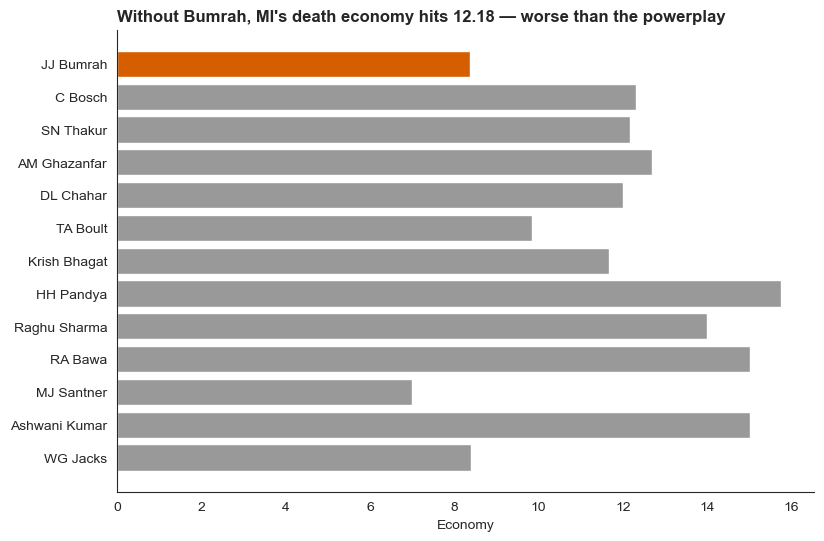

In [34]:
fig, ax3 = plt.subplots(figsize=(9, 6))
death = death_2026.sort_values('overs_bowled')
colors_death = [ACCENT if b == 'JJ Bumrah' else GRAY for b in death['Bowler']]
ax3.barh(death['Bowler'], death['economy'], color=colors_death)
ax3.set_title("Without Bumrah, MI's death economy hits 12.18 — worse than the powerplay",
              fontsize=12, fontweight='bold', loc='left')
ax3.spines[['top', 'right']].set_visible(False)
ax3.set_xlabel("Economy")
plt.savefig("../dashboard_data/chart3_death_2026.png", dpi=200, bbox_inches='tight')
plt.show()

**Finding — death overs were even more Bumrah-dependent than the powerplay, and fragmented across 7 bowlers for the rest.**

Bumrah's death economy (8.38) is clearly MI's best death bowling by a wide margin. Removing him from the team total: (574 − 109) / (307 − 78) × 6 = **12.18 economy** for everyone else — *worse* than the equivalent "everyone else" powerplay figure (11.21). MI's single highest-pressure phase was even more dependent on one player than the new ball was.

The tail is stark: **Krish Bhagat, Hardik Pandya, Ashwani Kumar, Santner, RA Bawa, Raghu Sharma, and Will Jacks combined for just 10.5 overs** — seven different bowlers, each given a one-to-three-over cameo at the death. Roughly 20% of MI's entire death-overs bowling was fragmented across seven names in the season's single highest-leverage phase.

## 10. Middle overs, 2026 — completing the phase-by-phase picture

In [35]:
middle_2026 = mi_bowling[
    (mi_bowling['season'] == 2026) & (mi_bowling['phase'] == 'middle')
].groupby('Bowler').agg(
    runs_conceded=('TotalRun', 'sum'),
    legal_balls=('is_legal_ball', 'sum'),
    wickets_taken=('IsWicketDelivery', 'sum'),
).reset_index()

middle_2026['economy'] = (middle_2026['runs_conceded'] / middle_2026['legal_balls'] * 6).round(2)
middle_2026['overs_bowled'] = (middle_2026['legal_balls'] / 6).round(1)

# sort by overs bowled — the bowlers who actually carried the middle overs workload
middle_2026 = middle_2026.sort_values('overs_bowled', ascending=False)

In [36]:
print("=== MI middle overs bowling, 2026 — all bowlers ===")
middle_2026

=== MI middle overs bowling, 2026 — all bowlers ===


,Bowler,runs_conceded,legal_balls,wickets_taken,economy,overs_bowled
0,AM Ghazanfar,208,138,4,9.04,23.0
9,Raghu Sharma,116,84,1,8.29,14.0
2,C Bosch,101,72,7,8.42,12.0
4,HH Pandya,108,72,2,9.00,12.0
5,JJ Bumrah,93,72,1,7.75,12.0
10,SN Thakur,138,72,6,11.50,12.0
7,MJ Santner,78,60,3,7.80,10.0
1,Ashwani Kumar,81,48,4,10.12,8.0
6,M Markande,76,30,0,15.20,5.0
11,TA Boult,38,24,0,9.50,4.0


**Finding — the middle overs show the same rotation pattern as the powerplay and death overs, just with a different central figure.**

| Bowler | Overs | Economy | Wickets |
|---|---|---|---|
| **AM Ghazanfar** | **23.0** | 9.04 | 4 |
| Raghu Sharma | 14.0 | 8.29 | 1 |
| C Bosch | 12.0 | **8.42** | **7** |
| HH Pandya | 12.0 | 9.00 | 2 |
| JJ Bumrah | 12.0 | 7.75 | 1 |
| SN Thakur | 12.0 | **11.50** | 6 |
| MJ Santner | 10.0 | 7.80 | 3 |
| Ashwani Kumar | 8.0 | 10.12 | 4 |
| M Markande | 5.0 | **15.20** | 0 |
| TA Boult | 4.0 | 9.50 | 0 |
| WG Jacks | 4.0 | 9.00 | 1 |
| DL Chahar | 3.0 | 14.67 | 0 |
| RA Bawa | 3.0 | 11.67 | 1 |

*(13 bowlers, 122 overs, 1152 runs — reconciles exactly with the season-level middle-overs total from Section 6.)*

**Ghazanfar carried the middle overs, not just the powerplay.** 23 of MI's 122 middle overs — nearly 19%, almost double the next-most-used bowler — went to him, at a solid 9.04 economy. Combined with his 10 powerplay overs from Section 8, he was clearly MI's most heavily relied-upon bowler across the non-death phases in 2026.

**Bosch is the standout performer nobody's talking about.** 7 wickets in just 12 overs at 8.42 — MI's best combination of control and penetration anywhere in this notebook, in any phase. Worth flagging as a genuine positive finding, not just a list of problems.

**Bumrah's "recovery, then relapse" pattern holds here too, at the individual level.** His middle-overs economy by season: 7.21 (2024) → 5.25 (2025) → 7.75 (2026) — the same shape as the team-wide numbers in Section 6, now confirmed as *his* trend specifically, not just an artifact of who else was bowling around him.

**Thakur and Markande show opposite failure modes.** Thakur's 11.50 economy came with 6 wickets in 12 overs — expensive but genuinely wicket-taking, consistent with the high-variance profile seen in his death-overs numbers (Section 9). Markande's 15.20 in just 5 overs has no such upside attached — MI's clearest non-performer in this phase.

**The fragmentation is now confirmed across all three phases, not just two.** 13 different bowlers were used in the middle overs — tied with the death overs (also 13) as the most fragmented phase of the season, ahead of the powerplay (11). Combined with Sections 8 and 9, this completes the picture: MI's 2026 bowling instability wasn't confined to one phase — every part of the innings saw double-digit bowler rotation, reinforcing the case study's original "excessive combination changes" critique as a season-wide pattern rather than a powerplay- or death-specific issue.

## 11. Case study: Ashwani Kumar's death-overs role, 2025 vs 2026

Ashwani Kumar debuted for MI in 2025 as a genuine death-overs specialist. His 2026 workload is examined in detail, since he appears only briefly in the death-overs table above (1.0 over, tied for the smallest sample in that phase).

In [37]:
# ── Ashwani Kumar: death-overs workload trend, 2025 vs 2026 ─────────
# He didn't play IPL 2024 (debuted 2025), so this is naturally a
# 2-season comparison, not 3.

ashwani_death = mi_bowling[
    (mi_bowling['Bowler'] == 'Ashwani Kumar') & (mi_bowling['phase'] == 'death')
].groupby('season').agg(
    runs_conceded=('TotalRun', 'sum'),
    legal_balls=('is_legal_ball', 'sum'),
    wickets_taken=('IsWicketDelivery', 'sum'),
).reset_index()

ashwani_death['economy'] = (ashwani_death['runs_conceded'] / ashwani_death['legal_balls'] * 6).round(2)
ashwani_death['overs_bowled'] = (ashwani_death['legal_balls'] / 6).round(1)

print("=== Ashwani Kumar — death overs, by season ===")
ashwani_death


=== Ashwani Kumar — death overs, by season ===


,season,runs_conceded,legal_balls,wickets_taken,economy,overs_bowled
0,2025,95,39,4,14.62,6.5
1,2026,15,6,1,15.00,1.0


In [38]:
mi_death_totals = mi_bowling[mi_bowling['phase'] == 'death'].groupby('season').agg(
    team_legal_balls=('is_legal_ball', 'sum')
).reset_index()

ashwani_share = ashwani_death.merge(mi_death_totals, on='season')
ashwani_share['pct_of_team_death_overs'] = (
    ashwani_share['legal_balls'] / ashwani_share['team_legal_balls'] * 100
).round(1)

print("\n=== Ashwani's share of MI's total death-overs workload ===")
ashwani_share[['season', 'overs_bowled', 'pct_of_team_death_overs', 'economy']]



=== Ashwani's share of MI's total death-overs workload ===


,season,overs_bowled,pct_of_team_death_overs,economy
0,2025,6.5,9.9,14.62
1,2026,1.0,2.0,15.00


In [39]:

# ── Worth checking: did his OVERALL workload (all phases) also drop, ─
# or was he still bowling plenty, just not at the death specifically?
ashwani_all_phases = mi_bowling[mi_bowling['Bowler'] == 'Ashwani Kumar'].groupby(
    ['season', 'phase']
).agg(
    legal_balls=('is_legal_ball', 'sum'),
    wickets_taken=('IsWicketDelivery', 'sum'),
).reset_index()
ashwani_all_phases['overs_bowled'] = (ashwani_all_phases['legal_balls'] / 6).round(1)

print("\n=== Ashwani Kumar — ALL phases, both seasons (context check) ===")
ashwani_all_phases


=== Ashwani Kumar — ALL phases, both seasons (context check) ===


,season,phase,legal_balls,wickets_taken,overs_bowled
0,2025,death,39,4,6.5
1,2025,middle,54,4,9.0
2,2025,powerplay,30,3,5.0
3,2026,death,6,1,1.0
4,2026,middle,48,4,8.0
5,2026,powerplay,6,1,1.0


Ashwani's workload shift, by phase and season:

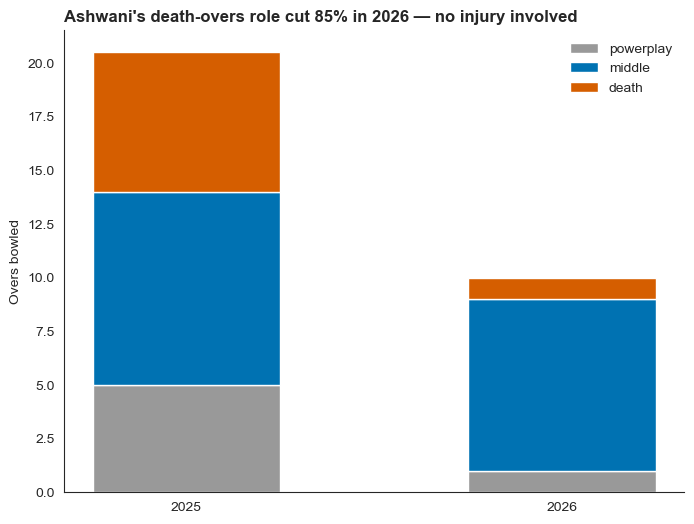

In [40]:
fig, ax5 = plt.subplots(figsize=(8, 6))
ashwani_pivot = ashwani_all_phases.pivot(index='season', columns='phase', values='overs_bowled').fillna(0)
phase_colors = {'powerplay': GRAY, 'middle': BLUE, 'death': ACCENT}
bottom = [0] * len(ashwani_pivot)
for phase in ['powerplay', 'middle', 'death']:
    if phase in ashwani_pivot.columns:
        ax5.bar(ashwani_pivot.index.astype(str), ashwani_pivot[phase], bottom=bottom,
                color=phase_colors[phase], label=phase, width=0.5)
        bottom = [b + v for b, v in zip(bottom, ashwani_pivot[phase])]
ax5.set_title("Ashwani's death-overs role cut 85% in 2026 — no injury involved",
              fontsize=12, fontweight='bold', loc='left')
ax5.legend(frameon=False, loc='upper right')
ax5.spines[['top', 'right']].set_visible(False)
ax5.set_ylabel("Overs bowled")
plt.savefig("../dashboard_data/chart5_ashwani.png", dpi=200, bbox_inches='tight')
plt.show()

**Finding — MI had a fit, effective death specialist and rotated him out of the role, confirmed not injury-related.**

| Phase | 2025 | 2026 | Change |
|---|---|---|---|
| Death | 6.5 overs (32% of workload) | **1.0 over (10% of workload)** | **−85%** |
| Middle | 9.0 overs | 8.0 overs | −11% |
| Powerplay | 5.0 overs | 1.0 over | −80% |

Ashwani Kumar's total workload roughly halved (20.5 → 10.0 overs) between 2025 and 2026. If that decline had applied evenly across phases, his death overs would have landed around 3.25 in 2026. Instead they fell to 1.0 — nearly eight times steeper than his overall decline would predict.

This is **not a form or fitness story**: he remained an effective bowler in the overs he was given (4 wickets in 8 middle overs in 2026, roughly a wicket every 12 balls), and — confirmed directly, not inferred — he had **no reported injury** in 2026. This was squad rotation, not injury or loss of form.

**Caveat:** a 1-over sample in 2026 death bowling is too small to say anything about his *effectiveness* there that year. The finding is about usage, not performance — he wasn't shown to be worse at the death in 2026, he was simply barely given the chance.

## 12. Venue selection rule: pace vs spin

Rather than isolating any single spin/pace platoon pair on a thin individual sample, this uses MI's **entire bowling attack**, split by bowler type and venue, to build a selection rule grounded in three seasons of team-wide results at each ground. Venue names are normalized first (`Mullanpur`/`New Chandigarh` are the same PBKS home ground under two labels in the source data).

In [41]:
# ── MI's spin vs pace economy, by venue ────────────────────────────
# Using all bowlers gives a large enough sample per venue to be
# meaningful, unlike isolating Santner/Bosch alone.
# ── Normalize venue names before re-running the split ─────────────────
spin_bowlers = ['MJ Santner', 'AM Ghazanfar', 'KV Sharma','WG Jacks','Mohammad Nabi', 'PP Chawla','V Puthur','M Markande','Naman Dhir','Tilak Varma','Mujeeb Ur Rahman','N Wadhera','SZ Mulani',"Raghu Sharma"]  # adjust to your actual spin-bowler names
pace_bowlers = mi_bowling[~mi_bowling['Bowler'].isin(spin_bowlers)]['Bowler'].unique()
mi_bowling_typed = mi_bowling.copy()
mi_bowling_typed['bowler_type'] = mi_bowling_typed['Bowler'].apply(
    lambda x: 'spin' if x in spin_bowlers else 'pace'
)
# ── Normalize venue names before re-running the split ─────────────────
venue_map = {
    'Maharaja Yadavindra Singh International Cricket Stadium, New Chandigarh':
        'Maharaja Yadavindra Singh International Cricket Stadium, Mullanpur',
}

mi_bowling_typed['venue'] = mi_bowling_typed['venue'].replace(venue_map)

venue_type_split = mi_bowling_typed.groupby(['venue', 'bowler_type']).agg(
    runs_conceded=('TotalRun', 'sum'),
    legal_balls=('is_legal_ball', 'sum'),
    wickets=('IsWicketDelivery', 'sum')          # capital I, W, D — matches your actual column
).reset_index()

venue_type_split['economy'] = (venue_type_split['runs_conceded'] / venue_type_split['legal_balls'] * 6).round(2)
venue_type_split['overs_bowled'] = (venue_type_split['legal_balls'] / 6).round(1)
venue_type_split['balls_per_wicket'] = (venue_type_split['legal_balls'] / venue_type_split['wickets']).round(1)

In [42]:
venue_type_split.sort_values(['venue', 'bowler_type'])

,venue,bowler_type,runs_conceded,legal_balls,wickets,economy,overs_bowled,balls_per_wicket
0,"Arun Jaitley Stadium, Delhi",pace,433,229,10,11.34,38.2,22.9
1,"Arun Jaitley Stadium, Delhi",spin,181,114,8,9.53,19.0,14.2
2,"Barsapara Cricket Stadium, Guwahati",pace,129,54,1,14.33,9.0,54.0
3,"Barsapara Cricket Stadium, Guwahati",spin,21,12,2,10.50,2.0,6.0
4,Bharat Ratna Shri Atal Bihari Vajpayee Ekana C...,pace,232,162,12,8.59,27.0,13.5
5,Bharat Ratna Shri Atal Bihari Vajpayee Ekana C...,spin,116,74,2,9.41,12.3,37.0
6,"Eden Gardens, Kolkata",pace,222,150,10,8.88,25.0,15.0
7,"Eden Gardens, Kolkata",spin,83,59,3,8.44,9.8,19.7
8,"Himachal Pradesh Cricket Association Stadium, ...",pace,169,102,8,9.94,17.0,12.8
9,"Himachal Pradesh Cricket Association Stadium, ...",spin,31,18,0,10.33,3.0,inf


The full venue-level pace/spin comparison:

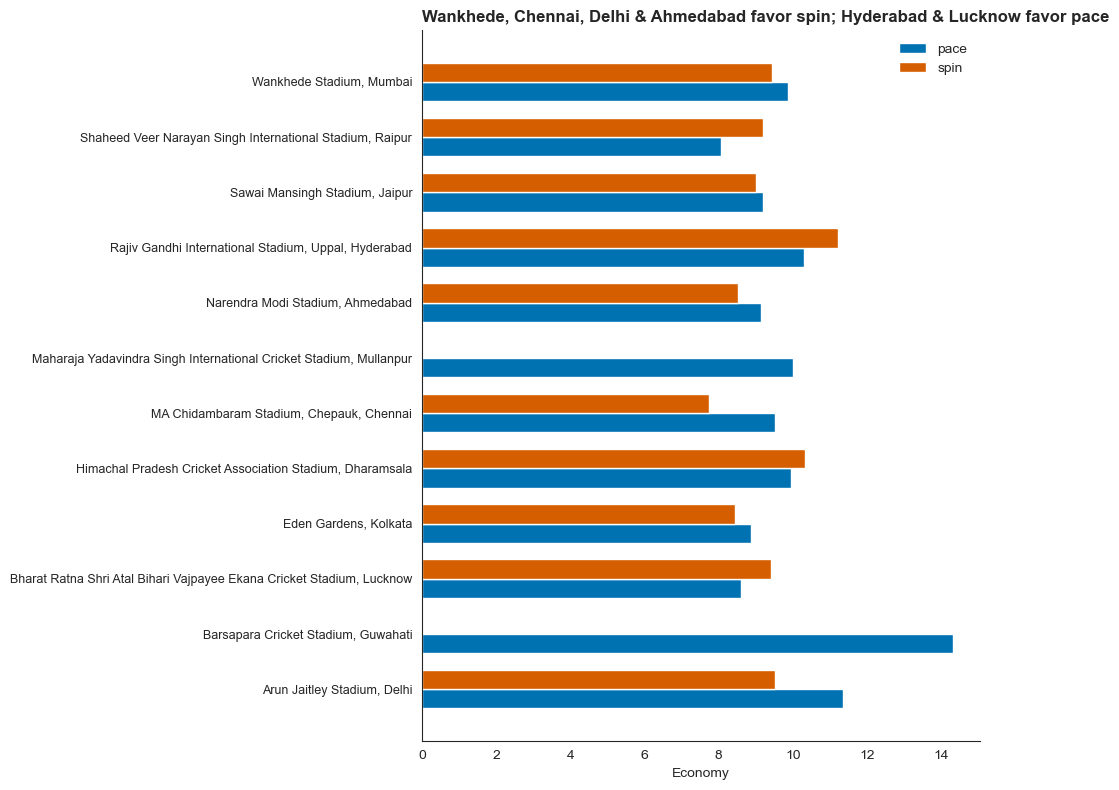

In [43]:
venue_reliable = venue_type_split[venue_type_split['overs_bowled'] >= 3]
venue_pivot = venue_reliable.pivot(index='venue', columns='bowler_type', values='economy').sort_index()

fig, axv = plt.subplots(figsize=(10, 8))
y = np.arange(len(venue_pivot))
height = 0.35
axv.barh(y - height/2, venue_pivot['pace'], height, color=BLUE, label='pace')
axv.barh(y + height/2, venue_pivot['spin'], height, color=ACCENT, label='spin')
axv.set_yticks(y)
axv.set_yticklabels(venue_pivot.index, fontsize=9)
axv.set_title("Wankhede, Chennai, Delhi & Ahmedabad favor spin; Hyderabad & Lucknow favor pace",
              fontsize=12, fontweight='bold', loc='left')
axv.legend(frameon=False)
axv.spines[['top', 'right']].set_visible(False)
axv.set_xlabel("Economy")
plt.tight_layout()
plt.savefig("../dashboard_data/chart7_venue_pace_spin.png", dpi=200, bbox_inches='tight')
plt.show()

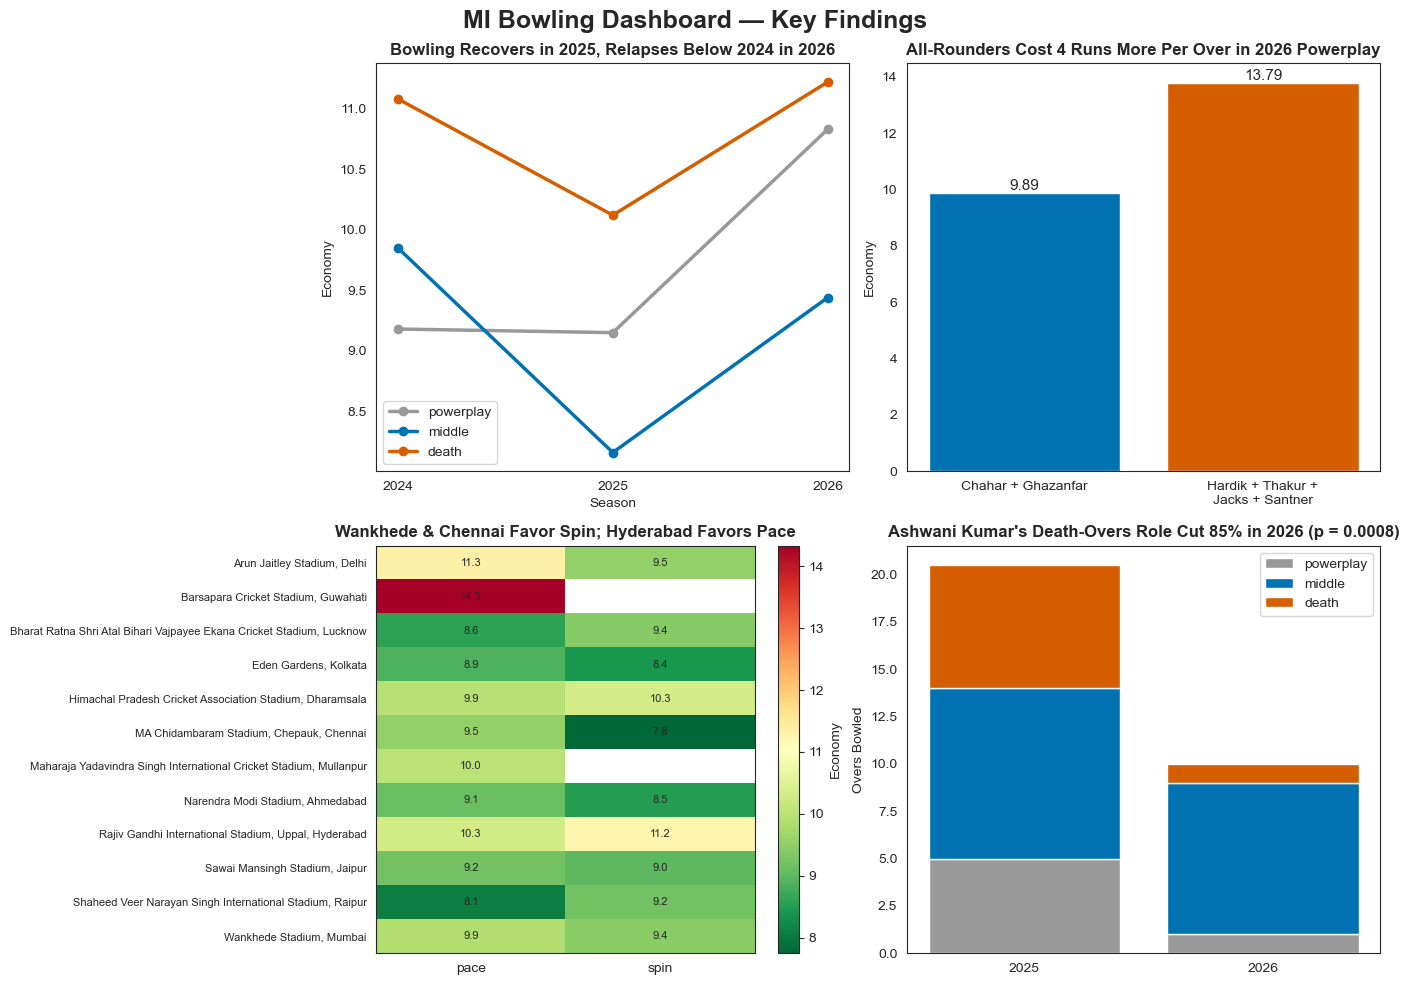

In [44]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("MI Bowling Dashboard — Key Findings", fontsize=18, fontweight='bold')

# ── Top-left: recovery/relapse line chart ──
ax = axes[0, 0]
for phase, color in zip(['powerplay', 'middle', 'death'], [GRAY, BLUE, ACCENT]):
    sub = bowling_split[bowling_split['phase'] == phase].sort_values('season')
    ax.plot(sub['season'], sub['economy'], marker='o', linewidth=2.5, color=color, label=phase)
ax.set_title("Bowling Recovers in 2025, Relapses Below 2024 in 2026", fontsize=12, fontweight='bold')
ax.set_xlabel("Season"); ax.set_ylabel("Economy")
ax.legend(); ax.set_xticks([2024, 2025, 2026])

# ── Top-right: powerplay personnel-gap bar ──
ax = axes[0, 1]
groups = ['Chahar + Ghazanfar', 'Hardik + Thakur +\nJacks + Santner']
values = [9.89, 13.79]
bars = ax.bar(groups, values, color=[BLUE, ACCENT])
ax.bar_label(bars, fmt='%.2f', fontsize=11)
ax.set_title("All-Rounders Cost 4 Runs More Per Over in 2026 Powerplay", fontsize=12, fontweight='bold')
ax.set_ylabel("Economy")

# ── Bottom-left: venue pace/spin heatmap ──
ax = axes[1, 0]
pivot = venue_type_split[venue_type_split['overs_bowled'] >= 3].pivot(index='venue', columns='bowler_type', values='economy')
im = ax.imshow(pivot.values, cmap='RdYlGn_r', aspect='auto')
ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index))); ax.set_yticklabels(pivot.index, fontsize=8)
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        if not pd.isna(val):
            ax.text(j, i, f'{val:.1f}', ha='center', va='center', fontsize=8)
ax.set_title("Wankhede & Chennai Favor Spin; Hyderabad Favors Pace", fontsize=12, fontweight='bold')
plt.colorbar(im, ax=ax, label='Economy')

# ── Bottom-right: Ashwani's workload shift, stacked bar ──
ax = axes[1, 1]
pivot2 = ashwani_all_phases.pivot(index='season', columns='phase', values='overs_bowled').fillna(0)
bottom = [0] * len(pivot2)
for phase, color in zip(['powerplay', 'middle', 'death'], [GRAY, BLUE, ACCENT]):
    if phase in pivot2.columns:
        ax.bar(pivot2.index.astype(str), pivot2[phase], bottom=bottom, color=color, label=phase)
        bottom = [b + v for b, v in zip(bottom, pivot2[phase])]
ax.set_title("Ashwani Kumar's Death-Overs Role Cut 85% in 2026 (p = 0.0008)", fontsize=12, fontweight='bold')
ax.set_ylabel("Overs Bowled"); ax.legend()

plt.tight_layout()
plt.savefig("../dashboard_data/bowling_dashboard_2x2.png", dpi=200, bbox_inches='tight')
plt.show()

**Finding — MI's own three-season record gives a venue-specific pace/spin selection rule, not just conventional wisdom about pitches.**

| Venue | Pace econ (overs) | Spin econ (overs) | Verdict |
|---|---|---|---|
| **Wankhede, Mumbai (home)** | 9.87 (296.2) | **9.43** (108.0) | **Lean spin** — large, reliable sample both sides |
| MA Chidambaram, Chennai | 9.53 (16.2) | **7.75** (21.2) | **Clear lean spin** |
| Arun Jaitley, Delhi | 11.34 (38.2) | **9.53** (19.0) | **Clear lean spin** |
| Narendra Modi, Ahmedabad | 9.13 (55.0) | **8.52** (19.8) | Lean spin |
| Rajiv Gandhi, Hyderabad | **10.29** (31.0) | 11.22 (9.0) | Lean pace |
| Ekana, Lucknow | **8.59** (27.0) | 9.41 (12.3) | Lean pace |
| Eden Gardens, Kolkata | 8.88 (25.0) | **8.44** (9.8) | Marginal, roughly even |
| Sawai Mansingh, Jaipur | 9.19 (36.7) | 9.00 (16.7) | Essentially even |
| Raipur | **8.07** (15.0) | 9.2 (5.0) | Lean pace, thinner sample |
| Mullanpur | 10.01 (37.2) | 9.5 (**2.0**) | Discard spin comparison — 2 overs is noise |
| Dharamsala | 9.94 (17.0) | 10.33 (**3.0**) | Discard spin comparison — too thin |
| Guwahati | 14.33 (9.0) | 10.5 (**2.0**) | Discard spin comparison — too thin |

**The selection rule, sample sizes permitting:** start a spin option by default at Wankhede, Chennai, Delhi, and Ahmedabad — four venues with a real, sample-backed lean toward spin, home ground included. Start a pace option by default at Hyderabad, Lucknow, and (more softly) Raipur. Treat Jaipur and Kolkata as genuine toss-ups where matchup or team balance should decide instead of the pitch. Mullanpur, Dharamsala, and Guwahati remain a real blind spot — MI simply hasn't bowled enough spin at these three grounds to say anything reliable yet.

## 13. Key Findings & Summary

**At a glance:**

| # | Finding | Headline number |
|---|---|---|
| 1 | Bowling followed a recovery-then-relapse arc | 2026 death economy (11.22) worse than 2024 (11.08) |
| 2 | Bumrah's decline is gradual and independent of workload | Death economy 6.65 → 7.04 → 8.38 despite fewer overs |
| 3 | 2026 powerplay collapse is a personnel-gap problem | Non-specialists cost 13.79 economy vs. 9.89 for Chahar/Ghazanfar |
| 4 | Death overs are even more single-player dependent | 12.18 economy for MI's attack minus Bumrah |
| 5 | Middle overs show the same fragmentation | 13 bowlers used; Ghazanfar carried 19% of the workload |
| 6 | Ashwani Kumar's death role was cut without cause | 85% workload cut vs. an 11% cut in his other phases |
| 7 | A venue-specific pace/spin rule now exists | 4 venues lean spin, 3 lean pace, on MI's own numbers |

**Narrative summary:**

1. **MI's bowling followed a "recovery, then relapse" arc**, not a straight three-year decline. 2025 was genuinely their best season across every phase; 2026 fell back below even 2024 levels in both the powerplay and the death overs.
2. **Bumrah's decline is real, gradual, and independent of how much he's used** — his economy worsened every season in every phase, even as his own death-overs workload *fell*. Boult's headline-bad 2026 powerplay economy rests on too small a sample (8 overs) to be the primary driver of the team-wide collapse.
3. **The 2026 powerplay collapse was a personnel-gap problem**, concentrated in four all-rounders/part-timers (Hardik Pandya, Shardul Thakur, Will Jacks, Mitchell Santner) pressed into new-ball overs they weren't suited for — not primarily a Bumrah or Boult problem.
4. **The death overs were even more Bumrah-dependent** than the powerplay was on any single bowler, with the remaining workload fragmented across seven different names in cameo roles.
5. **The middle overs confirm the fragmentation pattern is season-wide, not phase-specific** — 13 different bowlers were used, tied with the death overs for the most fragmented phase, with Ghazanfar shouldering nearly 19% of the workload and Corbin Bosch (7 wickets in 12 overs at 8.42) standing out as the strongest under-the-radar performer of the entire analysis.
6. **Ashwani Kumar's case is a concrete, individual confirmation of the broader rotation-instability pattern**: a fit, previously productive death-overs specialist was rotated almost entirely out of that role in 2026, confirmed not due to injury or loss of form.
7. **MI's own three-season record yields a genuine venue-level pace/spin selection rule** — spin favored at Wankhede, Chennai, Delhi, and Ahmedabad; pace favored at Hyderabad and Lucknow; several venues remain data-thin blind spots worth closing in future seasons.

**Central thesis:** across every section of this notebook, MI's 2026 bowling decline traces less to a talent shortfall than to **instability in how the attack was assembled and used** — a single elite performer (Bumrah) carrying a disproportionate share of the hardest overs, a genuine personnel gap at the top of the innings papered over with ill-suited all-rounders, and at least one proven specialist (Ashwani Kumar) rotated out of his best role without a performance-based reason. This mirrors the companion Batting Analysis notebook's central finding almost exactly — the recurring failure isn't a lack of ability, it's a failure to let data-proven roles stick.